In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import re
import warnings
from google.colab import drive

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
DATA_PATH = "/content/drive/MyDrive/independent-medical-review-imr-determinations-trends.csv"
OUTPUT_DIR = "results" # Directory to save results
MAX_TFIDF_FEATURES = 500    # Number of TF-IDF features

In [6]:
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Load the IMR CSV and prepare it for modeling

    Reads the CSV, creates a binary target variable from the Determination
    column (1 = Overturned, 0 = Upheld), fills missing demographic values,
    and combines text fields into a single column for TF-IDF

    Args:
        filepath (str): Path to the IMR CSV file

    Returns:
        pd.DataFrame: Cleaned DataFrame ready for feature engineering
    """
    print(f"Reading: {filepath}")
    df = pd.read_csv(filepath, low_memory=False, on_bad_lines="skip")
    print(f"Raw records: {len(df):,}")

    # Binary target: 1 = Overturned (favorable to patient), 0 = Upheld
    df["Overturned"] = df["Determination"].str.contains(
        "Overturned", case=False, na=False
    ).astype(int)

    # Fill missing demographics
    df["PatientGender"] = df["PatientGender"].fillna("Unknown").str.strip()
    df["AgeRange"] = df["AgeRange"].fillna("Unknown").str.strip()

    # Fill missing text fields
    text_cols = ["Findings", "DiagnosisCategory", "DiagnosisSubCategory",
                 "TreatmentCategory", "TreatmentSubCategory", "IMRType", "Type"]
    for col in text_cols:
        df[col] = df[col].fillna("").astype(str).str.strip()

    # Combined text field for TF-IDF
    df["combined_text"] = df[text_cols].apply(
        lambda row: " ".join(row.values), axis=1
    )

    print(f"Clean records: {len(df):,}")
    print(f"Target: {df['Overturned'].value_counts().to_dict()}")
    print(f"Gender: {df['PatientGender'].value_counts().to_dict()}")

    return df.reset_index(drop=True)

In [12]:
def explore_data(df: pd.DataFrame, output_dir: str):
    """
    Print and save overturn rates by gender and age group.

    Args:
        df (pd.DataFrame): Cleaned DataFrame from load_and_clean_data.
        output_dir (str): Directory to save exploration_stats.json.
    """
    os.makedirs(output_dir, exist_ok=True)  # <-- add this line

    overturn_by_gender = df.groupby("PatientGender")["Overturned"].mean()
    overturn_by_age = df.groupby("AgeRange")["Overturned"].mean()

    print(" -- Overturn Rates by Group --")
    for gender, rate in overturn_by_gender.items():
        print(f"Gender={gender}: {rate:.3f}")
    print()
    for age, rate in sorted(overturn_by_age.items()):
        print(f"Age={age}: {rate:.3f}")

    # Save stats to JSON
    stats = {
        "total_records": len(df),
        "target_distribution": df["Overturned"].value_counts().to_dict(),
        "gender_distribution": df["PatientGender"].value_counts().to_dict(),
        "age_distribution": df["AgeRange"].value_counts().to_dict(),
        "overturn_rate_by_gender": overturn_by_gender.to_dict(),
        "overturn_rate_by_age": overturn_by_age.to_dict(),
    }
    with open(os.path.join(output_dir, "exploration_stats.json"), "w") as f:
        json.dump(stats, f, indent=2, default=str)

In [8]:
print("Loading and cleaning data...")
df = load_and_clean_data(DATA_PATH)

Loading and cleaning data...
Reading: /content/drive/MyDrive/independent-medical-review-imr-determinations-trends.csv
Raw records: 40,921
Clean records: 40,921
Target: {1: 21152, 0: 19769}
Gender: {'Female': 23059, 'Male': 17086, 'Unknown': 691, 'Other': 85}


In [13]:
explore_data(df, OUTPUT_DIR)

 -- Overturn Rates by Group --
Gender=Female: 0.526
Gender=Male: 0.511
Gender=Other: 0.635
Gender=Unknown: 0.337

Age=0 to 10: 0.659
Age=11 to 20: 0.555
Age=21 to 30: 0.545
Age=31 to 40: 0.532
Age=41 to 50: 0.485
Age=51 to 64: 0.498
Age=65+: 0.454
Age=Unknown: 0.337


In [14]:
def clean_text(text: str) -> str:
    """
    Basic text cleaning for TF-IDF.

    Lowercases the text, removes special characters,
    and collapses extra whitespace.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [15]:
def build_features(df: pd.DataFrame, max_tfidf: int = 500):
    """
    Build the full feature matrix from the cleaned IMR data

    Combines TF-IDF text features, one-hot encoded demographics,
    one-hot encoded categorical columns, and the report year into
    a single sparse matrix

    Args:
        df (pd.DataFrame): Cleaned DataFrame from load_and_clean_data.
        max_tfidf (int): Maximum number of TF-IDF features to keep

    Returns:
        X: Sparse feature matrix (n_samples × n_features).
        y: Binary target array (1 = Overturned, 0 = Upheld).
        feature_names: List of feature names matching X's columns.
        sensitive_attrs: DataFrame with PatientGender and AgeRange
            for fairness evaluation
    """
    # TF-IDF on combined text (Term Frequency - Inverse Document Frequency)
    df["clean_text"] = df["combined_text"].apply(clean_text)

    tfidf = TfidfVectorizer(
        max_features=max_tfidf,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        sublinear_tf=True,
    )
    X_tfidf = tfidf.fit_transform(df["clean_text"])
    tfidf_names = [f"tfidf_{name}" for name in tfidf.get_feature_names_out()]

    # Demographic features (one-hot)
    gender_dummies = pd.get_dummies(df["PatientGender"], prefix="gender")
    age_dummies = pd.get_dummies(df["AgeRange"], prefix="age")

    # Categorical features (one-hot, top 20 per column)
    cat_cols = ["DiagnosisCategory", "TreatmentCategory", "IMRType", "Type"]
    cat_dummies_list = []
    cat_names = []
    for col in cat_cols:
        top_cats = df[col].value_counts().head(20).index
        temp = df[col].where(df[col].isin(top_cats), other="Other")
        dummies = pd.get_dummies(temp, prefix=col.lower())
        cat_dummies_list.append(dummies)
        cat_names.extend(list(dummies.columns))

    # Year feature
    year_feature = df[["ReportYear"]].fillna(df["ReportYear"].median())

    # Combine everything into one sparse matrix
    dense_parts = [gender_dummies.values, age_dummies.values]
    for cd in cat_dummies_list:
        dense_parts.append(cd.values)
    dense_parts.append(year_feature.values)

    X_dense = np.hstack(dense_parts)
    X = hstack([X_tfidf, csr_matrix(X_dense)])

    feature_names = (tfidf_names
                     + list(gender_dummies.columns)
                     + list(age_dummies.columns)
                     + cat_names
                     + ["ReportYear"])
    y = df["Overturned"].values
    sensitive_attrs = df[["PatientGender", "AgeRange"]].copy()

    print(f"TF-IDF features: {len(tfidf_names)}")
    print(f"Demographic features: {gender_dummies.shape[1] + age_dummies.shape[1]}")
    print(f"Categorical features: {len(cat_names)}")
    print(f"Total features: {X.shape[1]}")

    return X, y, feature_names, sensitive_attrs

In [16]:
def split_data(X, y, sensitive_attrs, test_size=0.2, random_state=42):
    """
    Stratified train/test split that keeps sensitive attributes aligned.

    Args:
        X: Feature matrix.
        y: Target array.
        sensitive_attrs: DataFrame with demographic columns.
        test_size (float): Fraction of data for testing.
        random_state (int): Random seed for reproducibility.

    Returns:
        X_train, X_test, y_train, y_test, sens_train, sens_test
    """
    indices = np.arange(len(y))
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=random_state, stratify=y
    )

    return (
        X[train_idx], X[test_idx],
        y[train_idx], y[test_idx],
        sensitive_attrs.iloc[train_idx].reset_index(drop=True),
        sensitive_attrs.iloc[test_idx].reset_index(drop=True),
    )

In [17]:
print("Building features (TF-IDF + demographics)...")
X, y, feature_names, sensitive_attrs = build_features(
    df, max_tfidf=MAX_TFIDF_FEATURES
)
X_train, X_test, y_train, y_test, sens_train, sens_test = split_data(
    X, y, sensitive_attrs
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {X.shape[1]}")


Building features (TF-IDF + demographics)...
TF-IDF features: 500
Demographic features: 12
Categorical features: 47
Total features: 560
Train: 32,736 | Test: 8,185 | Features: 560


In [18]:
# Only TF-IDF features (the text ones)
[f for f in feature_names if f.startswith("tfidf_")]

['tfidf_10',
 'tfidf_12',
 'tfidf_24',
 'tfidf_30',
 'tfidf_aba',
 'tfidf_ability',
 'tfidf_accepted',
 'tfidf_according',
 'tfidf_actively',
 'tfidf_actively practicing',
 'tfidf_actual',
 'tfidf_actual clinical',
 'tfidf_acute',
 'tfidf_addition',
 'tfidf_additional',
 'tfidf_additionally',
 'tfidf_administration',
 'tfidf_administration fda',
 'tfidf_adolescent',
 'tfidf_age',
 'tfidf_al',
 'tfidf_american',
 'tfidf_analysis',
 'tfidf_anti',
 'tfidf_anxiety',
 'tfidf_appropriate',
 'tfidf_approved',
 'tfidf_asam',
 'tfidf_associated',
 'tfidf_association',
 'tfidf_authorization',
 'tfidf_authorization coverage',
 'tfidf_authors',
 'tfidf_autism',
 'tfidf_available',
 'tfidf_available standard',
 'tfidf_based',
 'tfidf_basis',
 'tfidf_behavioral',
 'tfidf_beneficial',
 'tfidf_beneficial evaluation',
 'tfidf_beneficial treatment',
 'tfidf_benefit',
 'tfidf_bilateral',
 'tfidf_bmi',
 'tfidf_board',
 'tfidf_board certified',
 'tfidf_body',
 'tfidf_botox',
 'tfidf_breast',
 'tfidf_cancer

In [19]:
# Only gender features
[f for f in feature_names if f.startswith("gender_")]

['gender_Female', 'gender_Male', 'gender_Other', 'gender_Unknown']

In [20]:
# Only age features
[f for f in feature_names if f.startswith("age_")]

['age_0 to 10',
 'age_11 to 20',
 'age_21 to 30',
 'age_31 to 40',
 'age_41 to 50',
 'age_51 to 64',
 'age_65+',
 'age_Unknown']

In [21]:
# Train Logestic Regression
"""
Logistic Regression — Linear baseline.

Uses balanced class weights to handle imbalanced outcomes.
The SAGA solver supports both L1 and L2 regularization and
scales well to large datasets.
"""
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    C=1.0,
    random_state=42,
    n_jobs=-1,
)

lr_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [22]:
# Train Multinomial Naive Bayes
"""
Multinomial Naive Bayes — Probabilistic baseline.

Assumes feature independence, which means it cannot learn
interactions between demographic and clinical features.
Works natively with TF-IDF sparse matrices.
Alpha parameter controls Laplace smoothing.
"""
nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(X_train, y_train)
print("Multinomial Naive Bayes trained successfully.")

Multinomial Naive Bayes trained successfully.


In [23]:
# Train Random Forest
"""
Random Forest — Bagging ensemble.

Builds independent decision trees on random data subsets,
averaging their votes. The random feature selection at each
split naturally dilutes any single feature's influence.
"""
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [24]:
# Train AdaBoost
"""
AdaBoost — Sequential boosting ensemble.

Trains weak learners sequentially, giving more weight to
misclassified samples each round. If certain demographic
groups are harder to classify, AdaBoost will focus on them,
potentially amplifying existing data patterns.
"""
ada_model = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42,
    algorithm="SAMME",
)

ada_model.fit(X_train, y_train)
print("AdaBoost trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost trained successfully.


In [25]:
# Train XGBoost
"""
XGBoost — Advanced gradient boosting.

Uses regularized gradient boosting with level-wise tree growth.
Scale_pos_weight handles class imbalance. Industry standard
for tabular classification tasks.
"""
if XGBClassifier is not None:
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

    xgb_model.fit(X_train, y_train)
    print("XGBoost trained successfully.")
else:
    xgb_model = None
    print("XGBoost skipped because package is not installed.Install with: pip install xgboost")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:51:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained successfully.


In [26]:
# Train LightGBM
"""
LightGBM — Histogram-based gradient boosting (Microsoft).

Uses leaf-wise tree growth instead of level-wise, growing
deeper on the most informative splits first. This different
growth strategy may lead to different feature reliance
patterns compared to XGBoost.
"""
if LGBMClassifier is not None:
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    lgbm_model = LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

    lgbm_model.fit(X_train, y_train)
    print("LightGBM trained successfully.")
else:
    lgbm_model = None
    print("LightGBM skipped because package is not installed.")

LightGBM trained successfully.


In [27]:
# storing all trained models in one dictionary
models = {
    "Logistic Regression": lr_model,
    "Multinomial Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
}

if xgb_model is not None:
    models["XGBoost"] = xgb_model

if lgbm_model is not None:
    models["LightGBM"] = lgbm_model

print("Models ready for evaluation:")
print(list(models.keys()))

Models ready for evaluation:
['Logistic Regression', 'Multinomial Naive Bayes', 'Random Forest', 'AdaBoost', 'XGBoost', 'LightGBM']


In [28]:
def evaluate_one_model(model, X_test, y_test):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = np.zeros(len(y_test))

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

In [29]:
# evaluate all trained models
all_metrics = {}
predictions = {}
probabilities = {}

for model_name, model in models.items():
    metrics, y_pred, y_prob = evaluate_one_model(model, X_test, y_test)
    all_metrics[model_name] = metrics
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

performance_df = pd.DataFrame(all_metrics).T.sort_values("F1", ascending=False)
performance_df.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost,0.9344,0.9457,0.9263,0.9359,0.9859
LightGBM,0.9321,0.9412,0.9265,0.9338,0.9858
Random Forest,0.9076,0.9695,0.8480,0.9047,0.9810
AdaBoost,0.8822,0.9795,0.7887,0.8738,0.9719
Multinomial Naive Bayes,0.7718,0.8030,0.7400,0.7702,0.8507
Logistic Regression,0.6246,0.6390,0.6292,0.6340,0.6872


In [30]:
# best model based on the F1 score
best_model_name = performance_df.index[0]
best_model = models[best_model_name]

print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: XGBoost


In [31]:
# Classification report for best model
print(classification_report(y_test, predictions[best_model_name], zero_division=0))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      3954
           1       0.95      0.93      0.94      4231

    accuracy                           0.93      8185
   macro avg       0.93      0.93      0.93      8185
weighted avg       0.93      0.93      0.93      8185



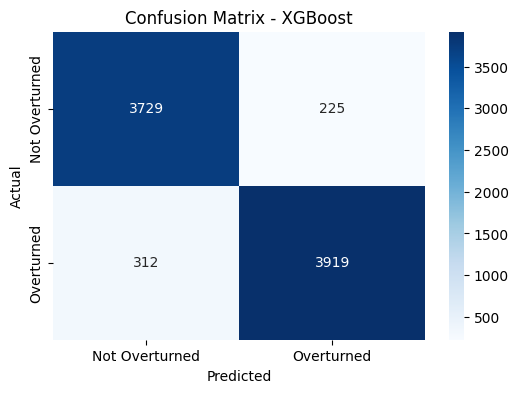

In [32]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Overturned", "Overturned"],
    yticklabels=["Not Overturned", "Overturned"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [33]:
def _group_metrics(y_true, y_pred, group_mask):
    """Compute TP, FP, TN, FN rates for a subgroup."""
    y_t = y_true[group_mask]
    y_p = y_pred[group_mask]
    n = len(y_t)

    if n == 0:
        return {"n": 0, "tpr": 0, "fpr": 0, "ppv": 0, "selection_rate": 0}

    tp = np.sum((y_t == 1) & (y_p == 1))
    fp = np.sum((y_t == 0) & (y_p == 1))
    tn = np.sum((y_t == 0) & (y_p == 0))
    fn = np.sum((y_t == 1) & (y_p == 0))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    selection_rate = np.mean(y_p)

    return {
        "n": n,
        "tpr": float(tpr),
        "fpr": float(fpr),
        "ppv": float(ppv),
        "selection_rate": float(selection_rate),
        "base_rate": float(np.mean(y_t)),
    }

In [34]:
def compute_fairness_metrics(model, X_test, y_test, sens_test) -> dict:
    """
    Compute comprehensive fairness metrics across gender and age.
    """
    y_pred = model.predict(X_test)
    results = {}

    # Gender Fairness
    gender_groups = {}
    for g in sens_test["PatientGender"].unique():
        mask = (sens_test["PatientGender"] == g).values
        if mask.sum() >= 10:
            gender_groups[g] = _group_metrics(y_test, y_pred, mask)

    if "Male" in gender_groups and "Female" in gender_groups:
        m = gender_groups["Male"]
        f = gender_groups["Female"]

        results["gender"] = {
            "groups": gender_groups,
            "demographic_parity_diff": abs(m["selection_rate"] - f["selection_rate"]),
            "equal_opportunity_diff": abs(m["tpr"] - f["tpr"]),
            "equalized_odds_tpr_diff": abs(m["tpr"] - f["tpr"]),
            "equalized_odds_fpr_diff": abs(m["fpr"] - f["fpr"]),
            "predictive_parity_diff": abs(m["ppv"] - f["ppv"]),
            "disparate_impact_ratio": (
                min(m["selection_rate"], f["selection_rate"])
                / max(m["selection_rate"], f["selection_rate"])
                if max(m["selection_rate"], f["selection_rate"]) > 0
                else 1.0
            ),
        }
    else:
        results["gender"] = {"groups": gender_groups, "note": "Insufficient groups"}

    # Age Fairness
    age_groups = {}
    for a in sens_test["AgeRange"].unique():
        mask = (sens_test["AgeRange"] == a).values
        if mask.sum() >= 10:
            age_groups[a] = _group_metrics(y_test, y_pred, mask)

    if len(age_groups) >= 2:
        selection_rates = [g["selection_rate"] for g in age_groups.values()]
        tprs = [g["tpr"] for g in age_groups.values()]
        fprs = [g["fpr"] for g in age_groups.values()]

        results["age"] = {
            "groups": age_groups,
            "max_selection_rate_diff": max(selection_rates) - min(selection_rates),
            "max_tpr_diff": max(tprs) - min(tprs),
            "max_fpr_diff": max(fprs) - min(fprs),
            "disparate_impact_ratio": (
                min(selection_rates) / max(selection_rates)
                if max(selection_rates) > 0
                else 1.0
            ),
        }
    else:
        results["age"] = {"groups": age_groups, "note": "Insufficient groups"}

    return results

In [35]:
def compute_all_fairness(models, X_test, y_test, sens_test):
    """Compute fairness metrics for all models."""
    all_fairness = {}
    for name, model in models.items():
        all_fairness[name] = compute_fairness_metrics(model, X_test, y_test, sens_test)
    return all_fairness

In [36]:
def print_fairness_report(fairness: dict, model_name: str):
    print(f"── Fairness Report: {model_name} ──")

    if "gender" in fairness and "demographic_parity_diff" in fairness["gender"]:
        g = fairness["gender"]
        print(f"Gender Fairness:")
        for group, metrics in g["groups"].items():
            print(
                f"{group:>8s}: n={metrics['n']:>5d}  "
                f"sel_rate={metrics['selection_rate']:.3f}  "
                f"TPR={metrics['tpr']:.3f}  FPR={metrics['fpr']:.3f}"
            )
        print(f"Demographic Parity Diff:   {g['demographic_parity_diff']:.4f}")
        print(f"Equal Opportunity Diff:     {g['equal_opportunity_diff']:.4f}")
        print(f"Equalized Odds (FPR diff):  {g['equalized_odds_fpr_diff']:.4f}")
        print(f"Predictive Parity Diff:     {g['predictive_parity_diff']:.4f}")
        print(f"Disparate Impact Ratio:     {g['disparate_impact_ratio']:.4f}")

        if g["disparate_impact_ratio"] < 0.8:
            print("DISPARATE IMPACT detected (ratio < 0.8, four-fifths rule)")
        if g["equal_opportunity_diff"] > 0.1:
            print("EQUAL OPPORTUNITY gap > 10%")

    if "age" in fairness and "max_selection_rate_diff" in fairness["age"]:
        a = fairness["age"]
        print(f"Age Fairness:")
        for group, metrics in sorted(a["groups"].items()):
            print(
                f"{group:>15s}: n={metrics['n']:>5d}  "
                f"sel_rate={metrics['selection_rate']:.3f}  "
                f"TPR={metrics['tpr']:.3f}"
            )
        print(f"Max Selection Rate Diff:    {a['max_selection_rate_diff']:.4f}")
        print(f"Max TPR Diff:               {a['max_tpr_diff']:.4f}")
        print(f"Disparate Impact Ratio:     {a['disparate_impact_ratio']:.4f}")

        if a["disparate_impact_ratio"] < 0.8:
            print("DISPARATE IMPACT detected across age groups")

In [37]:
def print_all_fairness(all_fairness):
    """Print fairness reports for all models."""
    for name, fairness in all_fairness.items():
        print_fairness_report(fairness, name)

In [38]:
def build_fairness_comparison_table(all_fairness):
    """Build a comparison DataFrame of key fairness metrics across models."""
    rows = []
    for model_name, fairness in all_fairness.items():
        row = {"Model": model_name}
        if "gender" in fairness and "demographic_parity_diff" in fairness["gender"]:
            g = fairness["gender"]
            row["Gender_DemParity"] = g["demographic_parity_diff"]
            row["Gender_EqualOpp"] = g["equal_opportunity_diff"]
            row["Gender_EqOdds_FPR"] = g["equalized_odds_fpr_diff"]
            row["Gender_PredParity"] = g["predictive_parity_diff"]
            row["Gender_DispImpact"] = g["disparate_impact_ratio"]
        if "age" in fairness and "max_selection_rate_diff" in fairness["age"]:
            a = fairness["age"]
            row["Age_MaxSelDiff"] = a["max_selection_rate_diff"]
            row["Age_DispImpact"] = a["disparate_impact_ratio"]
        rows.append(row)

    return pd.DataFrame(rows).set_index("Model")

In [39]:
print("Computing fairness metrics for all models...")
all_fairness = compute_all_fairness(models, X_test, y_test, sens_test)
print_all_fairness(all_fairness)

Computing fairness metrics for all models...
── Fairness Report: Logistic Regression ──
Gender Fairness:
  Female: n= 4630  sel_rate=0.527  TPR=0.625  FPR=0.419
    Male: n= 3397  sel_rate=0.500  TPR=0.645  FPR=0.345
 Unknown: n=  144  sel_rate=0.125  TPR=0.146  FPR=0.117
   Other: n=   14  sel_rate=0.714  TPR=0.889  FPR=0.400
Demographic Parity Diff:   0.0277
Equal Opportunity Diff:     0.0208
Equalized Odds (FPR diff):  0.0739
Predictive Parity Diff:     0.0410
Disparate Impact Ratio:     0.9475
Age Fairness:
        0 to 10: n=  565  sel_rate=0.857  TPR=0.907
       11 to 20: n=  913  sel_rate=0.793  TPR=0.846
       21 to 30: n=  731  sel_rate=0.681  TPR=0.806
       31 to 40: n= 1060  sel_rate=0.592  TPR=0.707
       41 to 50: n= 1450  sel_rate=0.377  TPR=0.488
       51 to 64: n= 2986  sel_rate=0.385  TPR=0.507
            65+: n=  336  sel_rate=0.351  TPR=0.456
        Unknown: n=  144  sel_rate=0.125  TPR=0.146
Max Selection Rate Diff:    0.7316
Max TPR Diff:               0.76

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


To put these numbers in context, we use the four-fifths rule which is a well-known standard that comes from U.S. employment discrimination law. The idea is simple: take the group that gets the lowest rate of favorable predictions and divide it by the group that gets the highest. If that ratio drops below 0.80, there's a fairness problem.

All six models treat male and female patients fairly similarly, with disparate impact ratios above 0.94 across the board. The gap in prediction rates between genders is small no matter which model we use, which suggests gender is not a major factor in how these models make their decisions.

Every single model fails the four-fifths rule. Younger patients, especially those 0 to 10, are predicted to get their claims overturned at higher rates  around 70-85% while older patients and those in the 41 to 64 range sit around 35-46%. Also note that this pattern shows up in all six models, from the simplest (Logistic Regression) to the most complex (LightGBM). The simpler models handle it the worst, Naive Bayes essentially stops predicting overturns entirely for one age group, giving it a disparate impact of 0.00. The boosting models do a better job narrowing the gap, but even they fall well short of the 0.80 threshold

In [40]:
# Fairness comparison table
fairness_df = build_fairness_comparison_table(all_fairness)
print("Fairness Comparison (Gender)")
gender_cols = [c for c in fairness_df.columns if c.startswith("Gender_")]
if gender_cols:
    print(fairness_df[gender_cols].round(4).to_string())

Fairness Comparison (Gender)
                         Gender_DemParity  Gender_EqualOpp  Gender_EqOdds_FPR  Gender_PredParity  Gender_DispImpact
Model                                                                                                              
Logistic Regression                0.0277           0.0208             0.0739             0.0410             0.9475
Multinomial Naive Bayes            0.0090           0.0101             0.0214             0.0224             0.9816
Random Forest                      0.0045           0.0143             0.0143             0.0156             0.9901
AdaBoost                           0.0150           0.0308             0.0169             0.0191             0.9649
XGBoost                            0.0130           0.0036             0.0017             0.0012             0.9747
LightGBM                           0.0125           0.0041             0.0002             0.0028             0.9759


In [41]:
print("Fairness Comparison (Age)")
age_cols = [c for c in fairness_df.columns if c.startswith("Age_")]
if age_cols:
    print(fairness_df[age_cols].round(4).to_string())

Fairness Comparison (Age)
                         Age_MaxSelDiff  Age_DispImpact
Model                                                  
Logistic Regression              0.7316          0.1459
Multinomial Naive Bayes          0.8159          0.0000
Random Forest                    0.4002          0.4157
AdaBoost                         0.3949          0.4189
XGBoost                          0.4126          0.4083
LightGBM                         0.4162          0.4062


Across all six models, the age-based fairness results reveal significant disparate impact, with every model falling well below the 0.80 threshold. The four tree-based models (Random Forest, AdaBoost, XGBoost, and LightGBM) cluster together with disparate impact ratios between 0.40 and 0.42, and the two simpler models show more extreme gaps, Logistic Regression at 0.15 and Naive Bayes at 0.00. The consistency of bias across different model architectures suggests that the disparity is rooted in the underlying data patterns rather than in any particular modeling choice. Particularly, the simpler models perform worse on fairness, indicating that they are less able to separate clinically relevant signals from age-related correlations in the data.

In [42]:
print("Four-Fifths Rule Check")
for model_name in fairness_df.index:
    if "Gender_DispImpact" in fairness_df.columns:
        di = fairness_df.loc[model_name, "Gender_DispImpact"]
        status = "PASS" if di >= 0.8 else "FAIL"
        print(f"{model_name:25s}: DI={di:.4f}  {status}")

Four-Fifths Rule Check
Logistic Regression      : DI=0.9475  PASS
Multinomial Naive Bayes  : DI=0.9816  PASS
Random Forest            : DI=0.9901  PASS
AdaBoost                 : DI=0.9649  PASS
XGBoost                  : DI=0.9747  PASS
LightGBM                 : DI=0.9759  PASS


In [43]:
print("Four-Fifths Rule Check (Age)")
for model_name in fairness_df.index:
    if "Age_DispImpact" in fairness_df.columns:
        di = fairness_df.loc[model_name, "Age_DispImpact"]
        status = "PASS" if di >= 0.8 else "FAIL"
        print(f"{model_name:25s}: DI={di:.4f}  {status}")

Four-Fifths Rule Check (Age)
Logistic Regression      : DI=0.1459  FAIL
Multinomial Naive Bayes  : DI=0.0000  FAIL
Random Forest            : DI=0.4157  FAIL
AdaBoost                 : DI=0.4189  FAIL
XGBoost                  : DI=0.4083  FAIL
LightGBM                 : DI=0.4062  FAIL


We need to understand what the models are actually relying on when they make predictions. Are they responding to clinically meaningful language in the review text, or are they picking up on age-related patterns that have nothing to do with medical necessity? To answer this, we rely on SHAP analysis, which lets us look inside each model and identify which specific features are driving its decisions across different demographic groups